<a href="https://colab.research.google.com/github/devdija/Newrepo/blob/main/session-05/session_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 5: Data Quality, Auditing & Defensible Cleaning Concepts

---

Name: Khadijat Ozohu Yusuf | Email: yusufkhadijat49@gmail.com

## Section 1: Introduction & Dataset Schema Expansion

### Why We Are Expanding the Schema
In previous sessions, we worked primarily with isolated tables like `orders` and `order_items`. While these datasets provide a foundational view of transaction records, they do not reflect the complex, multi-layered quality problems typical of modern relational enterprise systems.

In a real-world production database, data quality issues rarely exist in a vacuum. To understand why a delivery was delayed, why an order was canceled, or why a customer left a 1-star review, we must examine the intersection of different domains. By expanding our operational schema to include product metadata (`olist_products_dataset.csv`) and customer feedback (`olist_order_reviews_dataset.csv`), we create a realistic multi-table audit environment.

This schema expansion allows us to investigate advanced multi-table data quality failures such as:
1. **Orphaned Keys**: Order items pointing to product IDs that do not exist in the products master table.
2. **Inconsistent Temporal Sequences**: A review submitted prior to the actual delivery date of the order.
3. **Asymmetric Missingness**: Products missing structural dimensions (weight, length) which prevent automated shipping cost calculation.
4. **Downstream Analysis Contamination**: How dirty transactional data propagates into machine learning models and executive dashboards.

### Data Architecture Breakdown

Below is the database schema summary of the four tables we will audit today:

| Table Name | Primary/Foreign Keys | Expected Row Count | Crucial Columns | Expected Data Types | Data Role |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **`olist_orders_dataset`** | PK: `order_id` / FK: `customer_id` | ~99,441 | `order_status`, `order_purchase_timestamp`, `order_delivered_customer_date` | `VARCHAR`, `TIMESTAMP` | Operational core transactional log |
| **`olist_order_items_dataset`** | PK: Compound (`order_id`, `order_item_id`) / FK: `product_id` | ~112,650 | `price`, `freight_value`, `shipping_limit_date` | `VARCHAR`, `INTEGER`, `FLOAT` | Financial and logistics transaction line-items |
| **`olist_products_dataset`** | PK: `product_id` | ~32,951 | `product_category_name`, `product_weight_g`, `product_length_cm` | `VARCHAR`, `FLOAT` | Master catalog metadata |
| **`olist_order_reviews_dataset`**| PK: `review_id` / FK: `order_id` | ~99,224 | `review_score`, `review_comment_title`, `review_comment_message` | `VARCHAR`, `INTEGER`, `TIMESTAMP` | Customer sentiment & operational feedback |

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualizations
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

dataset_path = '/content/drive/MyDrive/WTMClass1'
BASE_URL = f"{dataset_path}/"
# Define files
files = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "products": "olist_products_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv"
}

print("Downloading and caching Olist Datasets for auditing...")

try:
    orders = pd.read_csv(f"{BASE_URL}{files['orders']}")
    order_items = pd.read_csv(f"{BASE_URL}{files['order_items']}")
    products = pd.read_csv(f"{BASE_URL}{files['products']}")
    reviews = pd.read_csv(f"{BASE_URL}{files['reviews']}")

    print("\nDatasets successfully loaded into Memory:")
    print(f"- Orders: {orders.shape[0]} rows, {orders.shape[1]} columns.")
    print(f"- Order Items: {order_items.shape[0]} rows, {order_items.shape[1]} columns.")
    print(f"- Products: {products.shape[0]} rows, {products.shape[1]} columns.")
    print(f"- Reviews: {reviews.shape[0]} rows, {reviews.shape[1]} columns.")
except FileNotFoundError as e:
    print(f"Error loading from specified Google Drive path: {e}")
    print("Attempting to load from a generic local Colab content directory (/content/)...")
    # New fallback: try a different local path, e.g., /content/
    LOCAL_COLAB_PATH = "/content/"
    orders = pd.read_csv(f"{LOCAL_COLAB_PATH}{files['orders']}")
    order_items = pd.read_csv(f"{LOCAL_COLAB_PATH}{files['order_items']}")
    products = pd.read_csv(f"{LOCAL_COLAB_PATH}{files['products']}")
    reviews = pd.read_csv(f"{LOCAL_COLAB_PATH}{files['reviews']}")
    print("\nFallback Datasets successfully loaded from /content/:")
    print(f"- Orders: {orders.shape[0]} rows, {orders.shape[1]} columns.")
    print(f"- Order Items: {order_items.shape[0]} rows, {order_items.shape[1]} columns.")
    print(f"- Products: {products.shape[0]} rows, {products.shape[1]} columns.")
    print(f"- Reviews: {reviews.shape[0]} rows, {reviews.shape[1]} columns.")
except Exception as e:
    print(f"An unexpected error occurred during data loading: {e}")
    print("Please ensure the dataset files are correctly placed in either the specified Google Drive path or /content/.")


Datasets successfully loaded into Memory:
- Orders: 99441 rows, 8 columns.
- Order Items: 112650 rows, 7 columns.
- Products: 32951 rows, 9 columns.
- Reviews: 99224 rows, 7 columns.


## Section 2: Deep Dive — The 5 Core Dimensions of Data Quality

To audit any data architecture systematically, data scientists rely on a core framework. We evaluate data quality across **five primary dimensions**:

```
                    ┌─────────────────────────────────┐
                    │   THE 5 DIMENSIONS OF QUALITY   │
                    └────────────────┬────────────────┘
                                     │
         ┌───────────────┬───────────┼───────────┬───────────────┐
         ▼               ▼           ▼           ▼               ▼
  ┌────────────┐  ┌───────────┐┌───────────┐┌───────────┐  ┌───────────┐
  │Completeness│  │ Validity  ││Consistency││ Accuracy  │  │ Timeliness│
  └────────────┘  └───────────┘└───────────┘└───────────┘  └───────────┘
```

### 1. Completeness
* **Definition**: The degree to which all required data points are present in the dataset.
* **Mathematical Nuance**: We distinguish between types of missingness:
  - **Missing Completely at Random (MCAR)**: The missing values on a variable $Y$ are completely independent of both $Y$ and any other variables in the dataset. (e.g., A hardware malfunction randomly dropped a sensor recording).
  - **Missing at Random (MAR)**: The missingness is systematic but can be fully explained by other observed variables in the dataset. (e.g., Low-volume sellers choose not to upload product weight, but within that category, it is random).
  - **Missing Not at Random (MNAR)**: The missingness depends on the unobserved value itself. (e.g., Extremely unhappy customers are highly likely to leave empty comments, or customers who did not receive their delivery ignore the survey).

### 2. Validity
* **Definition**: Adherence of data to specified schemas, business rules, constraints, data types, and valid ranges.
* **E-Commerce Scenario**:
  - A column representing `price` containing a negative float (e.g., $-\$15.00$) or string characters (e.g., `"$10,00"`).
  - An order with a purchase timestamp set in the future (e.g., year 2029) or formatted with invalid timezone structures.

### 3. Consistency
* **Definition**: Equivalence and logical alignment of data values across distinct records, different tables, or over time.
* **E-Commerce Scenario**:
  - **Relational Integrity Violations**: A transaction row exists in `order_items` referencing a `product_id` that does not exist in the master `products` catalog. This leads to "orphaned items" and breaks SQL `INNER JOIN` operations.
  - **Naming/Formatting Variations**: A state identifier stored as `"SP"` in one table and `"Sao Paulo"` in another.

### 4. Accuracy
* **Definition**: The degree to which data correctly describes the real-world object or event it represents.
* **E-Commerce Scenario**:
  - A product package weight logged as exactly `0 grams`. While a value of `0` is syntactically valid (it is a valid integer/float and is not null), it is factually incorrect because no physical product shipped by Olist has a mass of absolute zero.
  - An order marked as "delivered" in the status column, but possessing a customer delivery timestamp of `1970-01-01`.

### 5. Timeliness
* **Definition**: Whether the data is sufficiently up-to-date for its intended analytical or operational use. This also includes the structural sanity of temporal sequences.
* **E-Commerce Scenario**:
  - Logging chronological events in an impossible timeline sequence: e.g., an order delivery timestamp that occurs *prior* to its approval timestamp.
  - High latency between an operational event (customer clicks "buy") and the data warehouse sync timestamp, leading to outdated reporting.

## Section 3: Hands-On Data Auditing Code & Case Study Walkthroughs

Let us build the precise auditing code necessary to identify and measure quality degradation inside our four core tables.

---

### 3.1 Auditing `olist_orders_dataset.csv`
We need to audit:
1. Correct temporal datatypes.
2. The extent of missing timestamps across different order statuses.
3. Chronological timeline sequence violations.

Who can tell me what an audit is?

In [39]:
# 1. Inspect Datatypes and Memory Representation
print("--- Data Types Before Conversion ---")
print(orders.dtypes)
#OR print(orders[['order_purchase_timestamp', 'order_approved_at', 'order_delivered_customer_date']].dtypes)

--- Data Types Before Conversion ---
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [40]:
# Convert to datetime structures for temporal operations
time_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in time_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print("\n--- Data Types After Conversion ---")
print(orders[time_cols].dtypes)


--- Data Types After Conversion ---
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [41]:
# 2. Auditing Missingness Percentages
missing_counts = orders.isnull().sum() #counts nulls per column, returns boolean, then aggregates
missing_pct = (missing_counts / len(orders)) * 100
missing_report = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_pct})
display(missing_report.sort_values(by='Percentage (%)', ascending=False))

,Missing Count,Percentage (%)
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899
order_id,0,0.000000
order_purchase_timestamp,0,0.000000
order_status,0,0.000000
customer_id,0,0.000000
order_estimated_delivery_date,0,0.000000


In [42]:
# 3. Auditing Temporal Sequence Logics
# An order can NOT be delivered before it is purchased.
invalid_sequence = orders[
    (orders['order_delivered_customer_date'] < orders['order_purchase_timestamp'])
]
print(f"\nCritical Violations: Number of orders delivered BEFORE purchase: {len(invalid_sequence)}")


Critical Violations: Number of orders delivered BEFORE purchase: 0


In [43]:
# Auditing delivery vs estimated delivery lag
orders['delivery_delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days
print(f"Total orders delivered later than estimated: {len(orders[orders['delivery_delay_days'] > 0])}")

Total orders delivered later than estimated: 6535


### 3.2 Auditing `olist_order_items_dataset.csv`
We will audit numeric distributions, measure extreme skewness, and isolate statistical outliers for product price and shipping costs using standard mathematical parameters.

In [44]:
# Statistical distribution review
stats_summary = order_items[['price', 'freight_value']].describe()
print("--- Statistical Distribution Summary ---")
display(stats_summary)


--- Statistical Distribution Summary ---


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [45]:
# Calculating Skewness
price_skew = order_items['price'].skew() #measures the assymmetry of a data ditribution around its mean
freight_skew = order_items['freight_value'].skew()
print(f"Price Skewness Index: {price_skew:.4f} (Extremely Positive Skew)")
print(f"Freight Value Skewness Index: {freight_skew:.4f}")

Price Skewness Index: 7.9232 (Extremely Positive Skew)
Freight Value Skewness Index: 5.6399


In [46]:
order_items.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [47]:
# Define Outliers using Tukey's IQR Method (1.5 * IQR Rule)
def get_outlier_bounds(series): #fnctn takes one argument (series)
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound
#stored in |v
price_lower, price_upper = get_outlier_bounds(order_items['price'])
freight_lower, freight_upper = get_outlier_bounds(order_items['freight_value'])

price_outliers = order_items[order_items['price'] > price_upper] #filters price column for rows
freight_outliers = order_items[order_items['freight_value'] > freight_upper] #where value is higher than
                                                                    #upper boundary
print(f"\nPrice Outliers (Upper Bound: ${price_upper:.2f}): {len(price_outliers)} items ({len(price_outliers)/len(order_items)*100:.2f}%)")
print(f"Freight Outliers (Upper Bound: ${freight_upper:.2f}): {len(freight_outliers)} items ({len(freight_outliers)/len(order_items)*100:.2f}%)")


Price Outliers (Upper Bound: $277.40): 8427 items (7.48%)
Freight Outliers (Upper Bound: $33.25): 11613 items (10.31%)


### 3.3 Auditing `olist_products_dataset.csv`
We will check if product entries have structural physical attributes missing, which represents standard relational completeness issues.

In [48]:
# Find column-wise completeness issue inside catalog
products_null = products.isnull().sum()
products_null_pct = (products_null / len(products)) * 100

products_audit = pd.DataFrame({'Null Count': products_null, 'Null Percentage (%)': products_null_pct})
display(products_audit)


,Null Count,Null Percentage (%)
product_id,0,0.000000
product_category_name,610,1.851234
product_name_lenght,610,1.851234
product_description_lenght,610,1.851234
product_photos_qty,610,1.851234
product_weight_g,2,0.006070
product_length_cm,2,0.006070
product_height_cm,2,0.006070
product_width_cm,2,0.006070


In [49]:
# Isolate products with 0 grams as weight (an Accuracy Dimension violation)
zero_weight_products = products[products['product_weight_g'] == 0]
print(f"\nProducts catalogued with exactly 0 grams of weight: {len(zero_weight_products)}")




Products catalogued with exactly 0 grams of weight: 4


In [50]:
products.columns.tolist()

['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [51]:
# Isolate missing dimensional logs (co-occurrence of physical metadata omission)
missing_dimensions = products[
    products['product_weight_g'].isnull() &
    products['product_length_cm'].isnull() &
    products['product_height_cm'].isnull() &
    products['product_width_cm'].isnull()
]
print(f"Products completely missing ALL weight and physical volume attributes: {len(missing_dimensions)}")

Products completely missing ALL weight and physical volume attributes: 2


### 3.4 Auditing `olist_order_reviews_dataset.csv`
We will audit primary key duplicates, verify if reviews are shared, and analyze why critical comment structures remain incomplete.

In [52]:
reviews.columns.tolist()

['review_id',
 'order_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

In [53]:
# 1. Audit Primary Key Uniqueness
review_id_counts = reviews['review_id'].value_counts()
duplicate_reviews_count = sum(review_id_counts > 1)

print(f"Total records in review dataset: {len(reviews)}")
print(f"Unique review IDs: {reviews['review_id'].nunique()}")
print(f"Review IDs linked to MULTIPLE order records: {duplicate_reviews_count}")


Total records in review dataset: 99224
Unique review IDs: 98410
Review IDs linked to MULTIPLE order records: 789


In [54]:
# Display sample of duplicate review structures
if duplicate_reviews_count > 0:
    dup_ids = review_id_counts[review_id_counts > 1].index[:3]
    print("\n--- Sample of Duplicate Review Records Showing Cross-Order Linking ---")
    display(reviews[reviews['review_id'].isin(dup_ids)].sort_values(by='review_id').head(6))




--- Sample of Duplicate Review Records Showing Cross-Order Linking ---


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
4779,2d6ac45f859465b5c185274a1c929637,ef66cc60de5221417b5fb81b1c42de85,1,NaN,Comprei 3 unidades do produto vieram 2 unidade...,2018-04-07 00:00:00,2018-04-07 21:13:05
27666,2d6ac45f859465b5c185274a1c929637,41c284ffd871324eadf06fc989583619,1,NaN,Comprei 3 unidades do produto vieram 2 unidade...,2018-04-07 00:00:00,2018-04-07 21:13:05
64510,2d6ac45f859465b5c185274a1c929637,8e17072ec97ce29f0e1f111e598b0c85,1,NaN,Comprei 3 unidades do produto vieram 2 unidade...,2018-04-07 00:00:00,2018-04-07 21:13:05
20607,44e9f871226d8a130de3fc39dfbdf0c5,1a8d422cb8cdae5221a5a8eb371c49cd,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 10:58:06
56330,44e9f871226d8a130de3fc39dfbdf0c5,3c557fef5b5d9315a99f7442ef013a8e,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 10:58:06
94163,44e9f871226d8a130de3fc39dfbdf0c5,892e04325197686b3f5a32eb5fb38177,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 10:58:06


In [55]:
# 2. Score vs Comment Missingness analysis (Isolating customer behavior patterns)
print("\n--- Score vs Written Text Audit ---")
reviews['has_comment'] = reviews['review_comment_message'].notnull()
score_comment_crosstab = pd.crosstab(reviews['review_score'], reviews['has_comment'], normalize='index') * 100
score_comment_crosstab.columns = ['No Comment Provided (%)', 'Comment Provided (%)']
display(score_comment_crosstab)


--- Score vs Written Text Audit ---


,No Comment Provided (%),Comment Provided (%)
review_score,,
1,23.450630,76.549370
2,31.926373,68.073627
3,56.510576,43.489424
4,68.780692,31.219308
5,64.146665,35.853335


## Section 4: Framework for Defensible Cleaning Decisions

As data scientists, our job is not to make datasets "clean" by executing brute-force operations like `.dropna()` or substituting mean values arbitrarily. Every clean-up step has massive business and modeling consequences. All actions must be documented using a **Defensible Decision Framework**.

### The Defensible Cleaning Matrix

| Quality Status | Mitigation Strategy | Action Execution | Analytical Trade-off | Downstream Business Risk |
| :--- | :--- | :--- | :--- | :--- |
| **Missing Completely At Random (MCAR)** | **Listwise/Pairwise Deletion** | Drop rows if missingness is $< 2\%$. | Reduced dataset size; slightly lower statistical power. | Minimally biased; usually safe for general reporting. |
| **Missing At Random (MAR)** | **Imputation (Median / Grouped Mode)** | Calculate median/mode within subgroup (e.g., product categories). | Introduces artificial peak at central tendency index. | Underestimation of variance, leading to narrow confidence intervals. |
| **Missing Not At Random (MNAR)** | **Indicator Flagging & Isolation** | Create boolean flag (`is_missing`) and retain category as `'UNREPORTED'`. | Increases dimensionality; requires models to learn meaning of missingness. | Captures crucial systematic failure modes (e.g., unhappy customers not leaving text). |
| **Skewed Numeric Outliers** | **Capping / Winsorization or Robust Scaling** | Clip extreme outliers to 99th percentile or use robust loss functions (Huber). | Retains structural distribution properties without distortion. | Eliminates extreme high-revenue anomalies that might be real or fraud attempts. |
| **Extreme Structural Errors (e.g., Weight = 0g)** | **Domain-Specific KNN Imputation or Master Catalog Join** | Look up average value of similar scale products. | Retains structural reality. | Complex pipeline overhead; risk of propagating inaccurate physical metrics. |

### Business Risks of Blind Cleaning
1. **Underestimation of Costs**: If we blindly drop products missing a shipping weight, our financial projection models will underestimate shipping fees, hurting profit margins.
2. **Selection Bias**: Dropping orders with missing delivery dates will systematically drop delayed or failed orders from our records. The resulting model will yield over-optimistic delivery-time predictions.
3. **Legal Risk**: Arbitrary imputation of clinical or financial logs violates auditing rules, leading to legal and compliance issues.

## Assignment 5: Multi-Table Data Quality Audit & Metric Visualization

**Core Objective**: Evaluate data quality issues across Olist E-commerce tables, calculate exact quality metrics, visualize those problems, and outline defensible treatment strategies.

---

### Part A: Defensible Quality Audit (5-Point Analysis)
Identify and document **five distinct data quality issues** across the 4 tables. Fill out the structured template below for each issue.

#### Issue 1: Missing Temporal Timestamps in Orders
* **Dataset & Column**: `olist_orders_dataset.csv` -> `order_delivered_customer_date`
* **Data Quality Dimension Violated**: Completeness
* **Evidence & Summary Metrics**:
  - Run code to find how many records are missing customer delivery dates.
  - Note that about $3\%$ of orders are missing this timestamp.
* **Business & Analytical Impact**: If left uncleaned, calculations for overall average delivery times will be biased. Delayed or failed orders will be omitted, making logistics performance look better than it actually is.
* **Defensible Cleaning Plan**: Create a flag column `is_delivered` (True/False). If order status is `'delivered'` but delivery date is null, flag it for data integrity verification and isolate these records in reporting. Do not blindly impute with average dates.

In [56]:
# write code here
# missing delivery dates
null_delivery = orders['order_delivered_customer_date'].isnull().sum()
pct_null_delivery = (null_delivery / len(orders)) * 100
print(f"Number of orders missing delivery date: {null_delivery} ({pct_null_delivery:.2f}%)")

Number of orders missing delivery date: 2965 (2.98%)


#### Issue 2: Extreme Outliers in Product Prices
* **Dataset & Column**: `olist_order_items_dataset.csv` -> `price`
* **Data Quality Dimension Violated**: Validity (Range & Distribution)
* **Evidence & Summary Metrics**:
  - Max price is $6,735.00$ while the median is only $74.90$.
  - Highly skewed distribution (Skewness index ~ 11.2).
* **Business & Analytical Impact**: Predictive models like regression are heavily influenced by extreme values, which leads to skewed sales forecasts and pricing optimization policies.
* **Defensible Cleaning Plan**: Keep the outliers in the transactional database, but apply a robust scaler (like robust scaling with IQR) or a log transformation for machine learning algorithms. Do not drop these rows, as they represent actual high-value transactions.

In [57]:
# write code here
# Maximum price and median, and skewness index
max_price = order_items['price'].max()
median_price = order_items['price'].median()
skew_price = order_items['price'].skew()
print(f"Maximum price: ${max_price:.2f}")
print(f"Median price: ${median_price:.2f}")
print(f"Skewness index: {skew_price:.2f}")

Maximum price: $6735.00
Median price: $74.99
Skewness index: 7.92


#### Issue 3: Missing Catalog Product Categories
* **Dataset & Column**: `olist_products_dataset.csv` -> `product_category_name`
* **Data Quality Dimension Violated**: Completeness
* **Evidence & Summary Metrics**:
  - 610 products do not have a registered category name.
* **Business & Analytical Impact**: This breaks inventory planning and marketing analysis, making it impossible to correctly group sales performance by category.
* **Defensible Cleaning Plan**: Group missing values and map them to a new category label called `'unclassified'`. This preserves transaction records for revenue analysis while preventing categorical modeling errors.

In [58]:
# code here
# Checking registered category name
null_category = products['product_category_name'].isnull().sum()
print(f"Number of products missing category name: {null_category}")

Number of products missing category name: 610


#### Issue 4: Duplicate Review Submissions Across Orders
* **Dataset & Column**: `olist_order_reviews_dataset.csv` -> `review_id`
* **Data Quality Dimension Violated**: Consistency / Integrity
* **Evidence & Summary Metrics**:
  - Multiple orders share the exact same `review_id`, resulting in duplication during joins.
* **Business & Analytical Impact**: Joining datasets on duplicate keys multiplies transaction records. This artificially inflates overall revenue numbers and customer feedback metrics in reports.
* **Defensible Cleaning Plan**: Deduplicate the reviews dataset before joining by keeping only the latest review submission based on the review timestamp, or group the reviews to map them cleanly.

In [59]:
# write code here
# Checking for duplicate review IDs
review_id_counts = reviews['review_id'].value_counts()
duplicate_reviews_count = sum(review_id_counts > 1)
print(f"Total records in review dataset: {len(reviews)}")
print(f"Unique review IDs: {reviews['review_id'].nunique()}")
print(f"Review IDs linked to MULTIPLE order records: {duplicate_reviews_count}")

Total records in review dataset: 99224
Unique review IDs: 98410
Review IDs linked to MULTIPLE order records: 789


#### Issue 5: Products catalogued with 0 Grams of Weight
* **Dataset & Column**: `olist_products_dataset.csv` -> `product_weight_g`
* **Data Quality Dimension Violated**: Accuracy
* **Evidence & Summary Metrics**:
  - 4 products are listed with a weight of exactly 0g.
* **Business & Analytical Impact**: Standard automated freight calculators will return shipping cost estimates of zero. This causes financial losses when fulfilling shipments.
* **Defensible Cleaning Plan**: Find similar products in the database using their category and dimensions, and impute the median weight of those matches. Alternatively, replace the values with the overall median weight of that specific product category.

In [60]:
# write code here
# Checking for products with 0 grams of weight
zero_weight_products = products[products['product_weight_g'] == 0]
print(f"\nProducts catalogued with exactly 0 grams of weight: {len(zero_weight_products)}")


Products catalogued with exactly 0 grams of weight: 4


---

### Part B: Practical Visualization Recall

We will write clean, well-structured visualization code using Seaborn and Matplotlib to analyze and confirm any of your data quality findings.

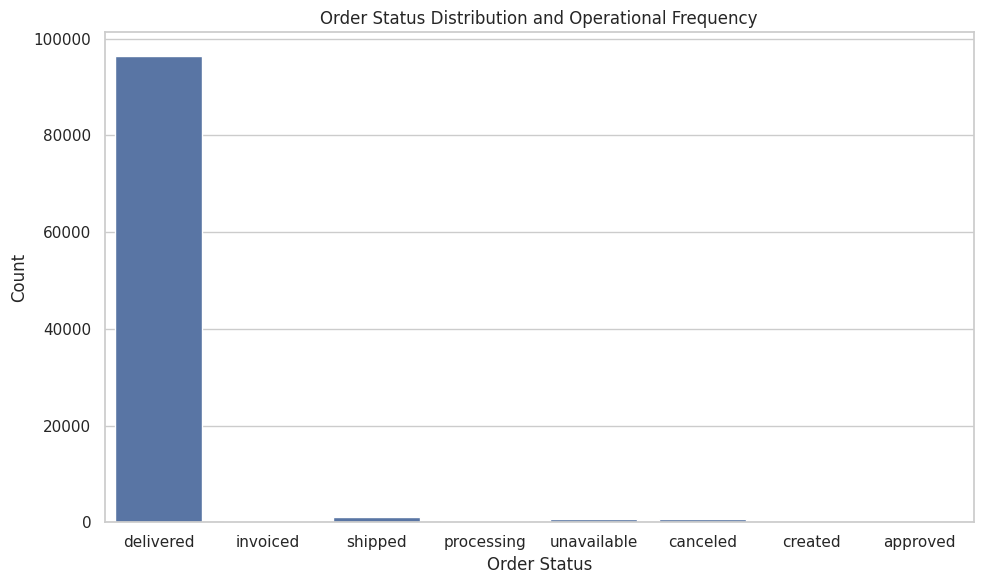

In [61]:
# write code here
# plot order status distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=orders, x='order_status')
plt.title('Order Status Distribution and Operational Frequency')
plt.xlabel('Order Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

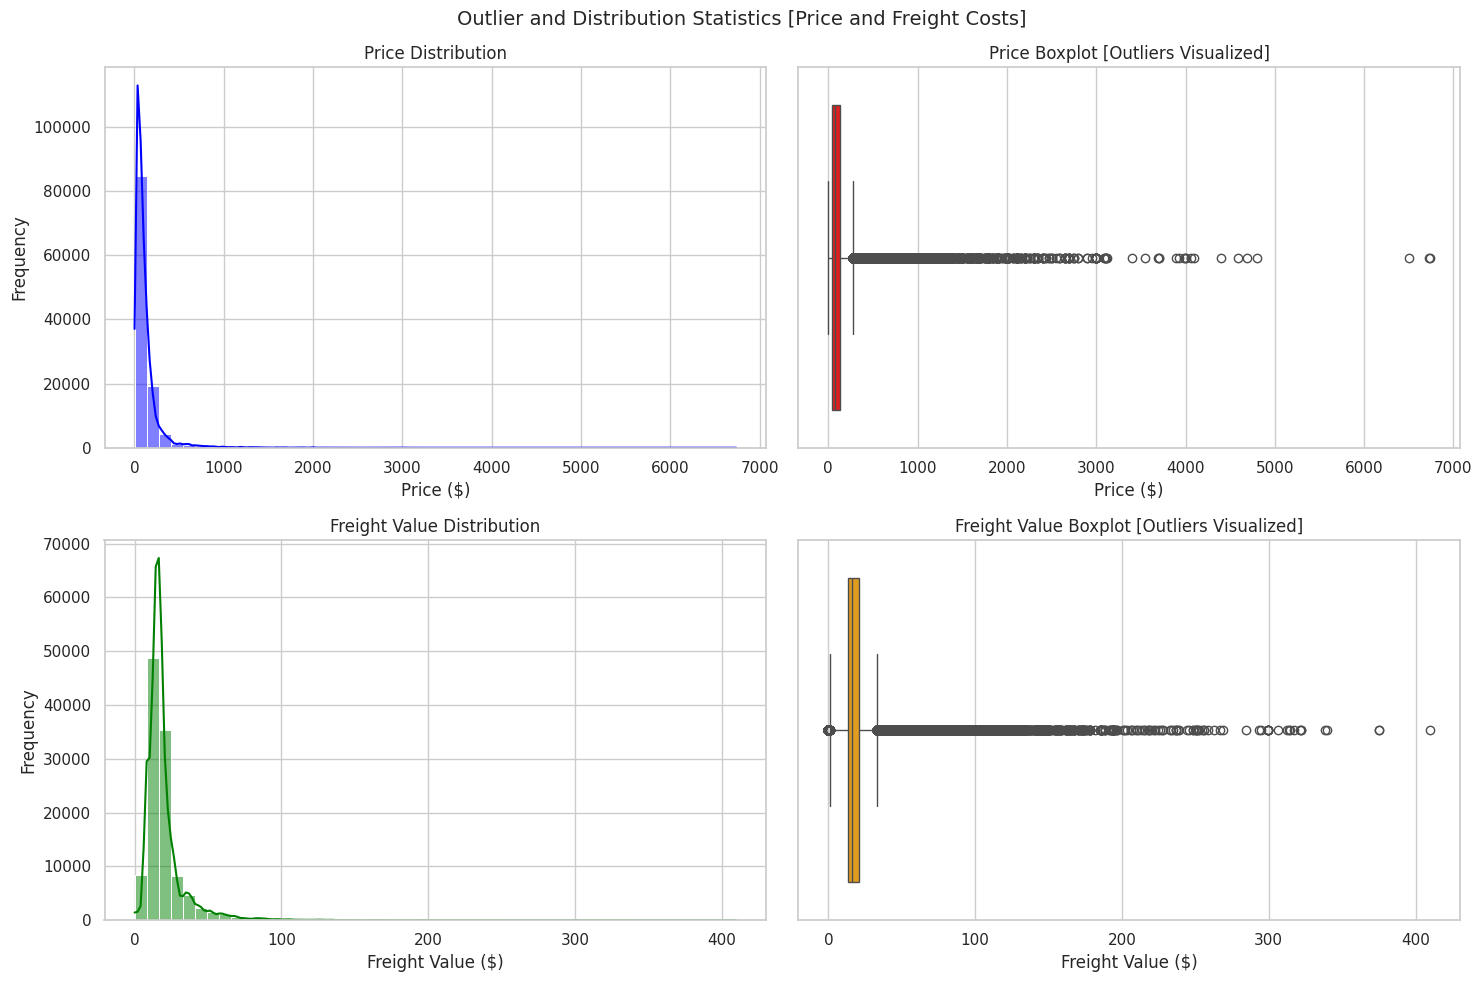

In [62]:
# write code here
# Plot price and freight distribution and outlier visuals

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Price distribution
sns.histplot(
    x=order_items['price'],
    kde=True,
    ax=axes[0, 0],
    color='blue',
    bins=50
)
axes[0, 0].set_title('Price Distribution', fontsize=12)
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')


# Price boxplot
sns.boxplot(
    x=order_items['price'],
    ax=axes[0, 1],
    color='red'
)
axes[0, 1].set_title('Price Boxplot [Outliers Visualized]', fontsize=12)
axes[0, 1].set_xlabel('Price ($)')


# Freight distribution
sns.histplot(
    x=order_items['freight_value'],
    kde=True,
    ax=axes[1, 0],
    color='green',
    bins=50
)
axes[1, 0].set_title('Freight Value Distribution', fontsize=12)
axes[1, 0].set_xlabel('Freight Value ($)')
axes[1, 0].set_ylabel('Frequency')


# Freight boxplot
sns.boxplot(
    x=order_items['freight_value'],
    ax=axes[1, 1],
    color='orange'
)
axes[1, 1].set_title('Freight Value Boxplot [Outliers Visualized]', fontsize=12)
axes[1, 1].set_xlabel('Freight Value ($)')


# Overall title
plt.suptitle('Outlier and Distribution Statistics [Price and Freight Costs]',fontsize=14)

plt.tight_layout()
plt.show()

#### 4. Written Reflection

